# OW Yellow Caps — Notebook 4: Multivariate EDA

**Client:** OW Yellow Caps  
**Data:** NYC TLC Yellow Taxi · Jan–Mar 2025 (post-cleaning)  
**Purpose:** Three-or-more variable combinations to uncover deeper operational patterns.

## Coverage (per TOR §6.3)
1. Time × Geography × Demand (hour × zone × trips)
2. Geography × Payment Type × Revenue (zone × PT × revenue)
3. Distance × Duration × Total Amount (joint distribution)
4. Month × Hour × Borough-proxy (temporal evolution of demand pattern)
5. Pre/Post CBD × Geography × Fare (impact of congestion pricing by zone)
6. Vendor × Payment Type × Revenue (vendor market intelligence)
7. Pair plot: core financial and operational variables

**Principles applied:** faceting, small multiples, parallel coordinate insight,
as taught in the course *Data Visualisation* and *Best Practices* slides.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.titleweight': 'bold'})

CLEAN_PATH = 'yellow_taxi_clean.parquet'
df = pd.read_parquet(CLEAN_PATH)
print(f'Loaded: {len(df):,} rows × {df.shape[1]} columns')

PT_LABELS  = {0:'Flex Fare', 1:'Credit Card', 2:'Cash',
               3:'No Charge', 4:'Dispute', 5:'Unknown', 6:'Voided'}
VENDOR_LABELS = {1:'Creative Mobile', 2:'Curb Mobility',
                 6:'Myle Technologies', 7:'Helix'}
DOW_ORDER  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
MONTH_MAP  = {1:'January', 2:'February', 3:'March'}
print('Setup complete.')

Loaded: 10,448,657 rows × 33 columns
Setup complete.


---
## 1. Time × Geography × Demand

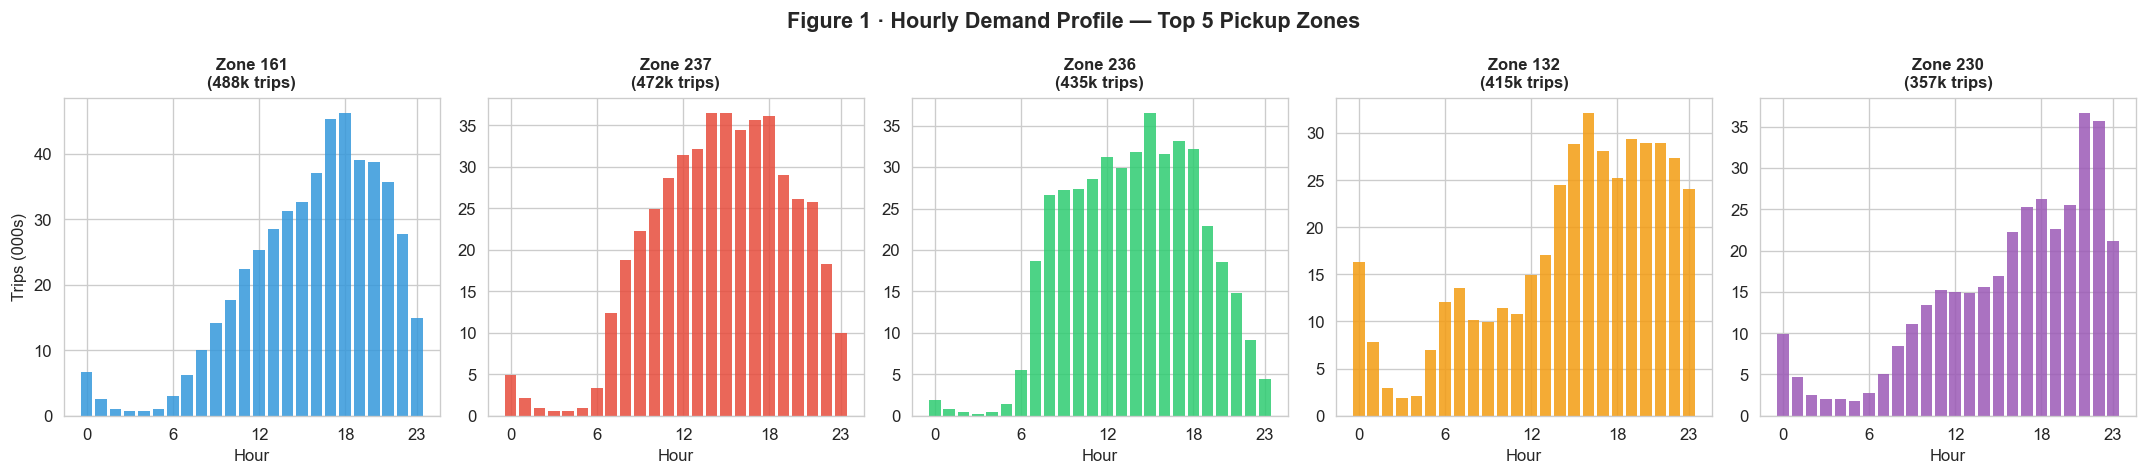

In [2]:
# Top 5 pickup zones by total volume
top5_zones = df.groupby('PULocationID').size().nlargest(5).index.tolist()

hourly_zone = (
    df[df.PULocationID.isin(top5_zones)]
    .groupby(['PULocationID', 'pickup_hour'])
    .size()
    .reset_index(name='trips')
)

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']

for ax, zone, color in zip(axes, top5_zones, colors):
    zdata = hourly_zone[hourly_zone.PULocationID == zone]
    vol = df[df.PULocationID == zone].shape[0]
    ax.bar(zdata.pickup_hour, zdata.trips / 1000, color=color, edgecolor='none', alpha=0.85)
    ax.set_title(f'Zone {zone}\n({vol/1000:.0f}k trips)', fontsize=10)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Trips (000s)' if ax == axes[0] else '')
    ax.set_xticks([0, 6, 12, 18, 23])

fig.suptitle('Figure 1 · Hourly Demand Profile — Top 5 Pickup Zones',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

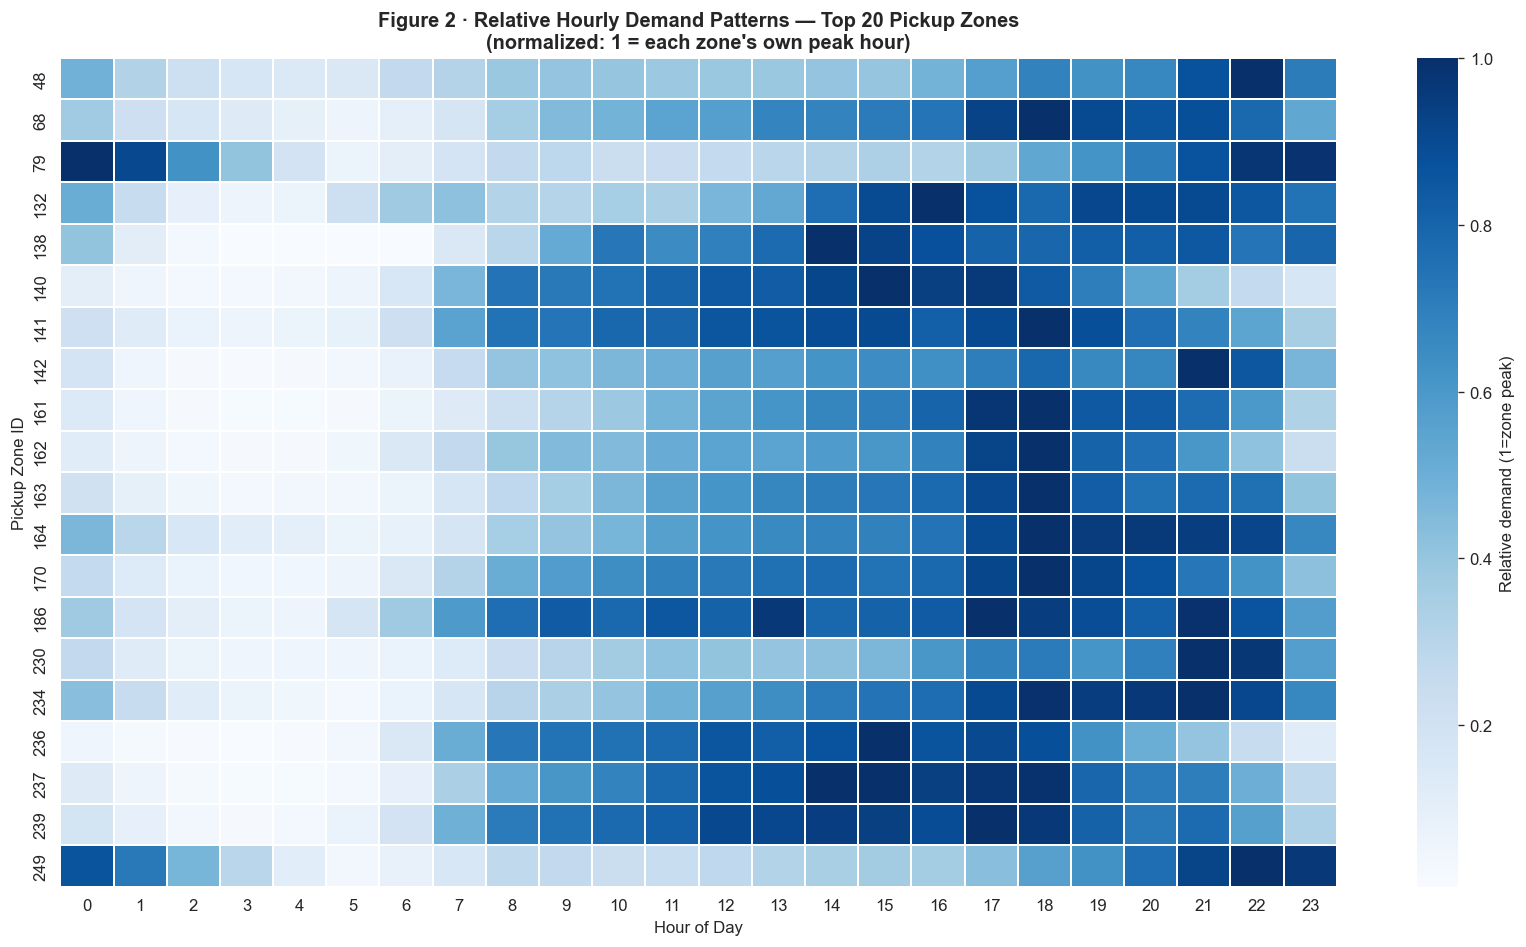

In [3]:
# ── Heatmap: Hour × Zone (top 20 zones) ──────────────────────────────────
top20_zones = df.groupby('PULocationID').size().nlargest(20).index.tolist()

zone_hour = (
    df[df.PULocationID.isin(top20_zones)]
    .groupby(['PULocationID', 'pickup_hour'])
    .size()
    .unstack(fill_value=0)
)
# Normalize by max per zone (row) to show relative demand patterns
zone_hour_norm = zone_hour.div(zone_hour.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(zone_hour_norm, cmap='Blues', ax=ax, linewidths=0.2,
            cbar_kws={'label': 'Relative demand (1=zone peak)'})
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Pickup Zone ID')
ax.set_title('Figure 2 · Relative Hourly Demand Patterns — Top 20 Pickup Zones\n'
             '(normalized: 1 = each zone\'s own peak hour)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 2. Geography × Payment Type × Revenue

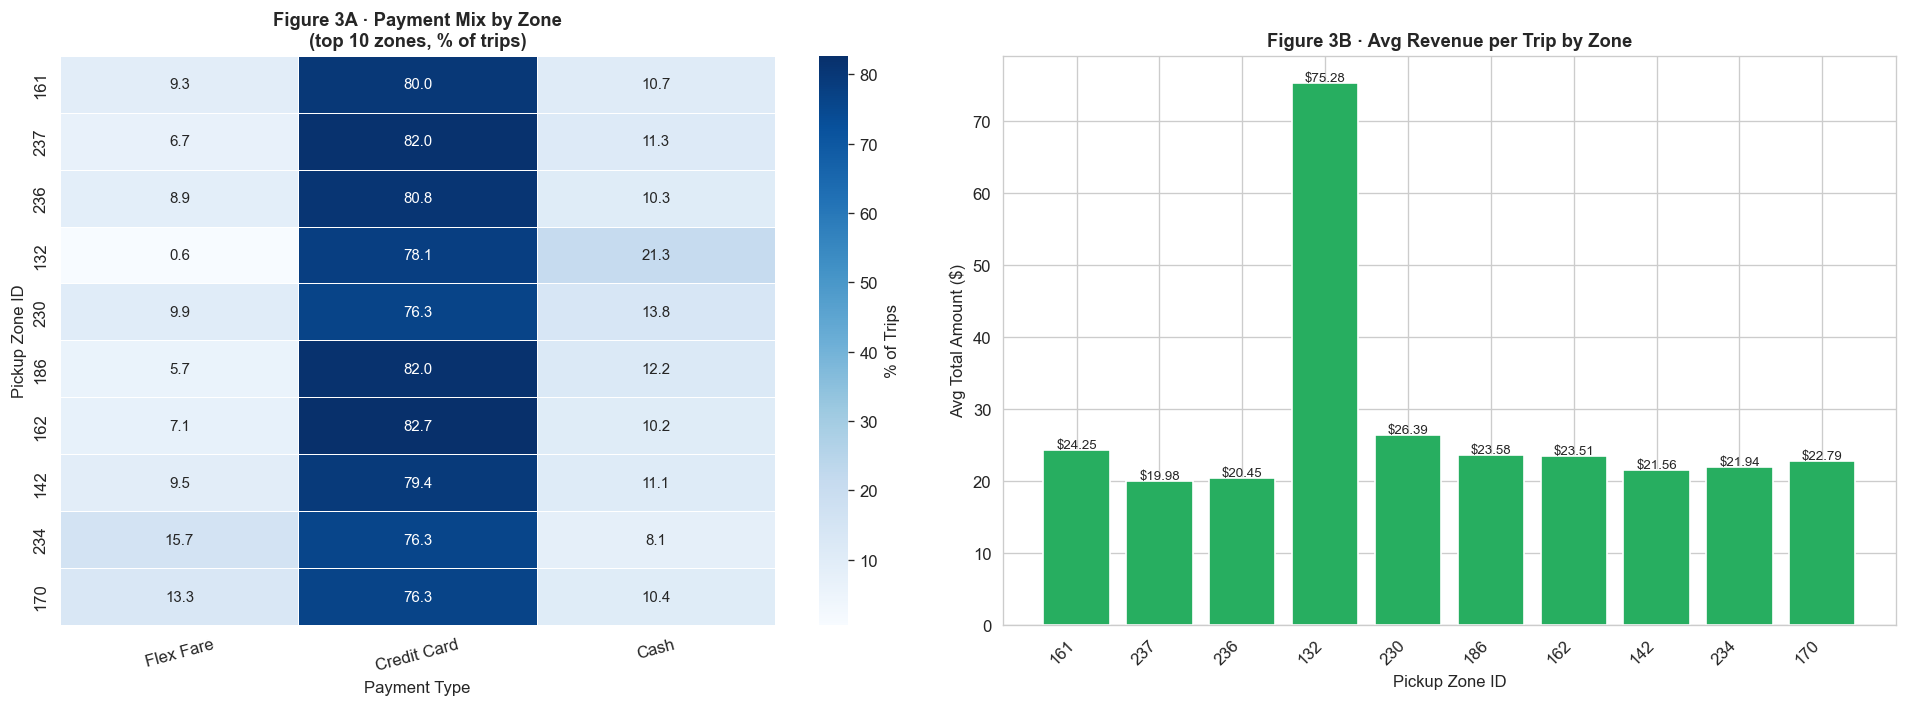

In [5]:
# Top 10 zones: payment type mix and revenue per trip
top10_zones = df.groupby('PULocationID').size().nlargest(10).index.tolist()

geo_pt = (
    df[df.PULocationID.isin(top10_zones) & df.payment_type.isin([0, 1, 2])]
    .groupby(['PULocationID', 'payment_type'])
    .agg(trips=('trip_id','count'), revenue=('total_amount','sum'))
    .reset_index()
)

# Pivot for heatmap
pivot_trips = geo_pt.pivot(index='PULocationID', columns='payment_type', values='trips').fillna(0)
pivot_trips.columns = [PT_LABELS[c] for c in pivot_trips.columns]
pivot_trips = pivot_trips.reindex(top10_zones)

# Normalize to 100% for proportional view
pivot_pct = pivot_trips.div(pivot_trips.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of payment mix % by zone
sns.heatmap(pivot_pct, ax=axes[0], cmap='Blues', annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': '% of Trips'},
            annot_kws={'size': 9})
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Pickup Zone ID')
axes[0].set_title('Figure 3A · Payment Mix by Zone\n(top 10 zones, % of trips)')
axes[0].tick_params(axis='x', rotation=15)

# Avg revenue per trip by zone
avg_rev = (
    df[df.PULocationID.isin(top10_zones)]
    .groupby('PULocationID')['total_amount'].mean()
    .reindex(top10_zones)
)
bars = axes[1].bar(avg_rev.index.astype(str), avg_rev.values,
                   color='#27ae60', edgecolor='white')
for bar, v in zip(bars, avg_rev.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'${v:.2f}', ha='center', fontsize=8)
axes[1].set_xlabel('Pickup Zone ID')
axes[1].set_ylabel('Avg Total Amount ($)')
axes[1].set_title('Figure 3B · Avg Revenue per Trip by Zone')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## 3. Distance × Duration × Total Amount (Joint Distribution)

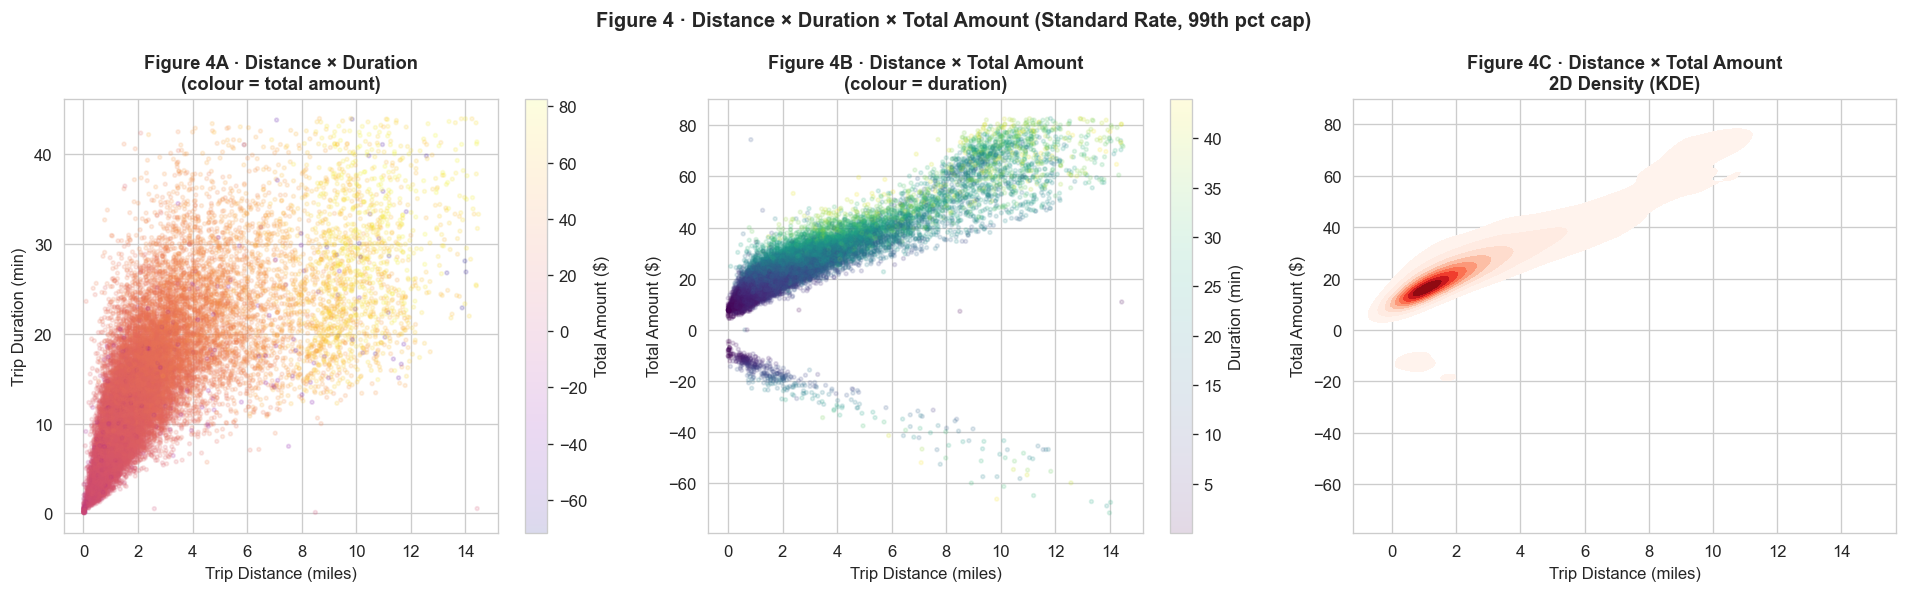

In [9]:
# Sample 30k standard-rate trips for 3D visualization
sample_std = df[df.RatecodeID == 1.0].sample(min(30_000, len(df)), random_state=42)
dist_cap  = sample_std.trip_distance.quantile(0.99)
dur_cap   = sample_std.trip_duration_min.quantile(0.99)
total_cap = sample_std.total_amount.quantile(0.99)

sdata = sample_std[
    (sample_std.trip_distance <= dist_cap) &
    (sample_std.trip_duration_min <= dur_cap) &
    (sample_std.total_amount <= total_cap)
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1: Distance vs Duration, colored by total_amount
sc1 = axes[0].scatter(sdata.trip_distance, sdata.trip_duration_min,
                       c=sdata.total_amount, cmap='plasma', alpha=0.15, s=5)
plt.colorbar(sc1, ax=axes[0], label='Total Amount ($)')
axes[0].set_xlabel('Trip Distance (miles)')
axes[0].set_ylabel('Trip Duration (min)')
axes[0].set_title('Figure 4A · Distance × Duration\n(colour = total amount)')

# 2: Distance vs Total Amount, colored by Duration
sc2 = axes[1].scatter(sdata.trip_distance, sdata.total_amount,
                       c=sdata.trip_duration_min, cmap='viridis', alpha=0.15, s=5)
plt.colorbar(sc2, ax=axes[1], label='Duration (min)')
axes[1].set_xlabel('Trip Distance (miles)')
axes[1].set_ylabel('Total Amount ($)')
axes[1].set_title('Figure 4B · Distance × Total Amount\n(colour = duration)')

# 3: 2D KDE of distance vs total amount
sns.kdeplot(data=sdata, x='trip_distance', y='total_amount',
            cmap='Reds', fill=True, ax=axes[2], thresh=0.05)
axes[2].set_xlabel('Trip Distance (miles)')
axes[2].set_ylabel('Total Amount ($)')
axes[2].set_title('Figure 4C · Distance × Total Amount\n2D Density (KDE)')

fig.suptitle('Figure 4 · Distance × Duration × Total Amount (Standard Rate, 99th pct cap)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

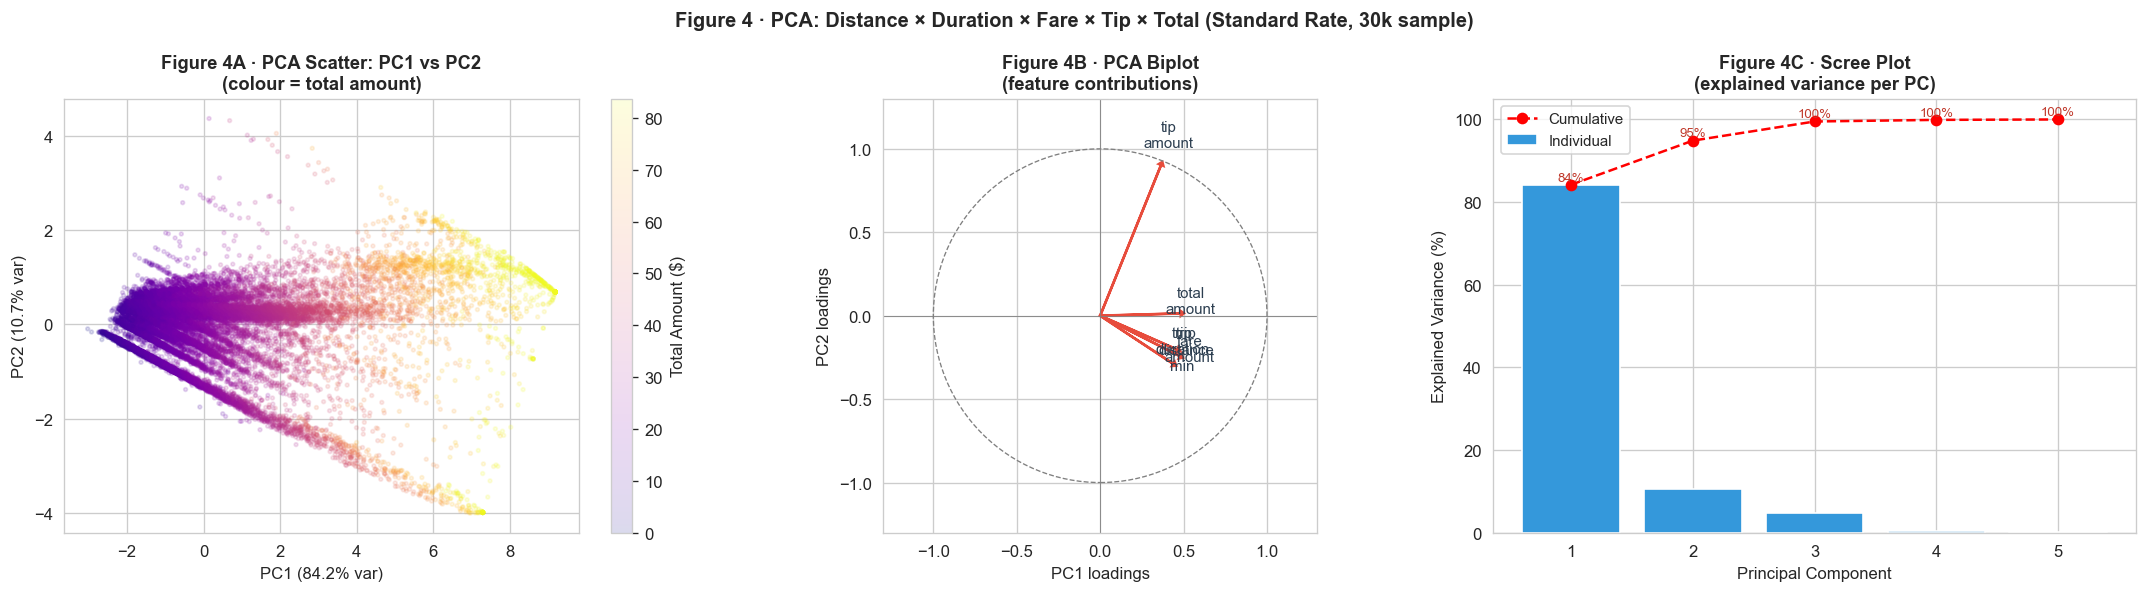

Explained variance ratio:
  PC1: 84.20%
  PC2: 10.67%
  PC3: 4.63%
  PC4: 0.39%
  PC5: 0.10%

PC1 + PC2 capture: 94.9% of total variance


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Sample standard-rate trips with non-negative fares
sample_std = df[(df.RatecodeID == 1.0) & (df.fare_amount >= 0)].sample(min(30_000, len(df)), random_state=42)

pca_cols = ['trip_distance', 'trip_duration_min', 'fare_amount', 'tip_amount', 'total_amount']
sdata = sample_std[pca_cols].dropna()

# Cap at 99th percentile per column
for col in pca_cols:
    cap = sdata[col].quantile(0.99)
    sdata[col] = sdata[col].clip(upper=cap)

# Standardise and fit PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(sdata)
pca = PCA(n_components=len(pca_cols))
components = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 · Scatter PC1 vs PC2, coloured by total_amount
sc = axes[0].scatter(components[:, 0], components[:, 1],
                     c=sdata['total_amount'], cmap='plasma',
                     alpha=0.15, s=5)
plt.colorbar(sc, ax=axes[0], label='Total Amount ($)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('Figure 4A · PCA Scatter: PC1 vs PC2\n(colour = total amount)')

# 2 · Biplot: feature loadings on PC1 & PC2
loadings = pca.components_[:2].T
for i, col in enumerate(pca_cols):
    axes[1].arrow(0, 0, loadings[i, 0], loadings[i, 1],
                  head_width=0.03, head_length=0.02,
                  fc='#e74c3c', ec='#e74c3c', lw=1.5)
    axes[1].text(loadings[i, 0] * 1.12, loadings[i, 1] * 1.12,
                 col.replace('_', '\n'), ha='center', fontsize=9, color='#2c3e50')
circle = plt.Circle((0, 0), 1, color='grey', fill=False, linestyle='--', lw=0.8)
axes[1].add_patch(circle)
axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-1.3, 1.3)
axes[1].axhline(0, color='grey', lw=0.5)
axes[1].axvline(0, color='grey', lw=0.5)
axes[1].set_xlabel('PC1 loadings')
axes[1].set_ylabel('PC2 loadings')
axes[1].set_title('Figure 4B · PCA Biplot\n(feature contributions)')
axes[1].set_aspect('equal')

# 3 · Explained variance (scree plot)
ev = pca.explained_variance_ratio_ * 100
cumev = np.cumsum(ev)
axes[2].bar(range(1, len(ev)+1), ev, color='#3498db', edgecolor='white', label='Individual')
axes[2].plot(range(1, len(ev)+1), cumev, 'ro--', markersize=6, label='Cumulative')
for i, (v, c) in enumerate(zip(ev, cumev)):
    axes[2].text(i+1, c + 1, f'{c:.0f}%', ha='center', fontsize=8, color='#c0392b')
axes[2].set_xlabel('Principal Component')
axes[2].set_ylabel('Explained Variance (%)')
axes[2].set_title('Figure 4C · Scree Plot\n(explained variance per PC)')
axes[2].set_xticks(range(1, len(ev)+1))
axes[2].legend(fontsize=9)

fig.suptitle('Figure 4 · PCA: Distance × Duration × Fare × Tip × Total (Standard Rate, 30k sample)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Explained variance ratio:')
for i, v in enumerate(pca.explained_variance_ratio_, 1):
    print(f'  PC{i}: {v*100:.2f}%')
print(f'\nPC1 + PC2 capture: {pca.explained_variance_ratio_[:2].sum()*100:.1f}% of total variance')

---
## 4. Month × Hour × Demand (Temporal Evolution)

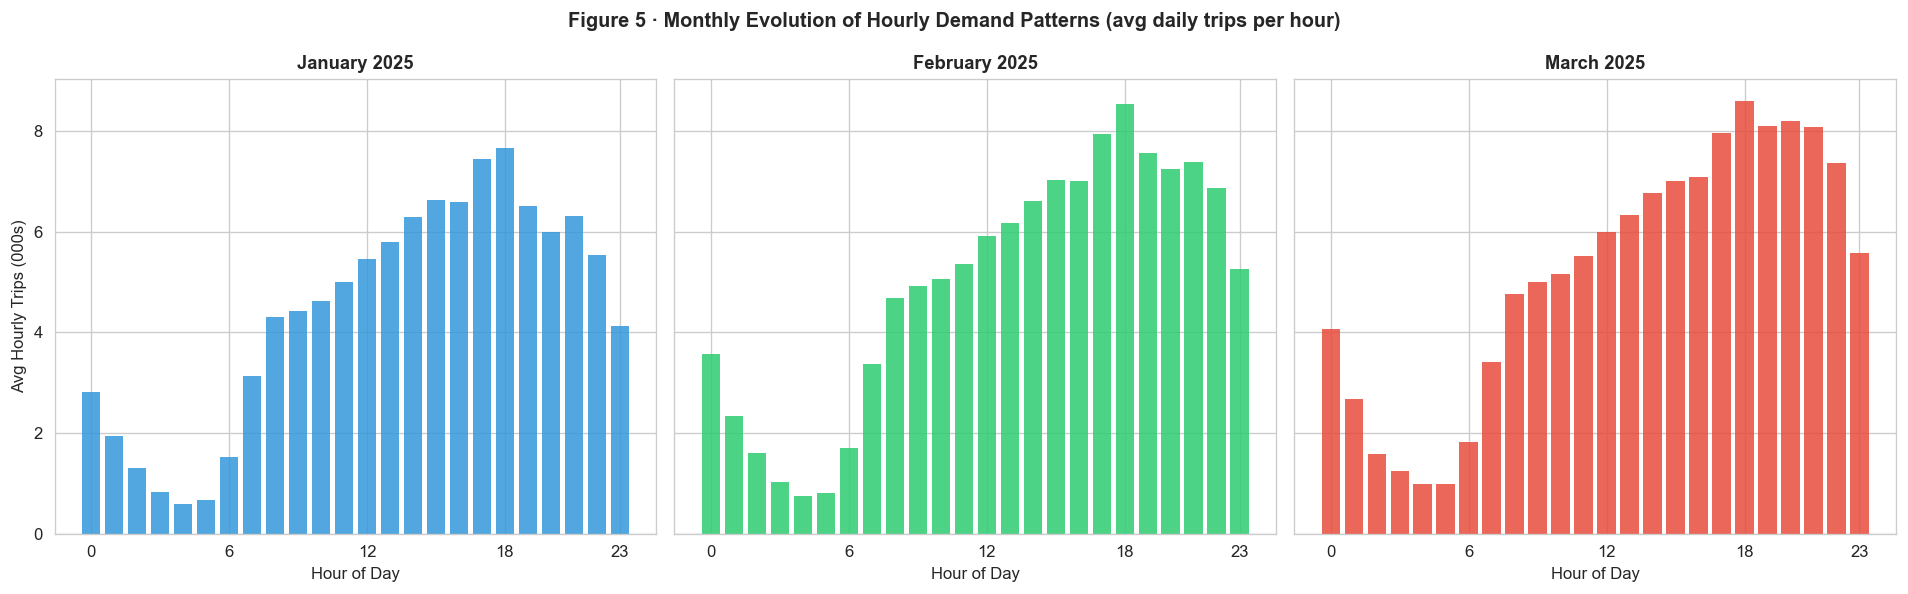

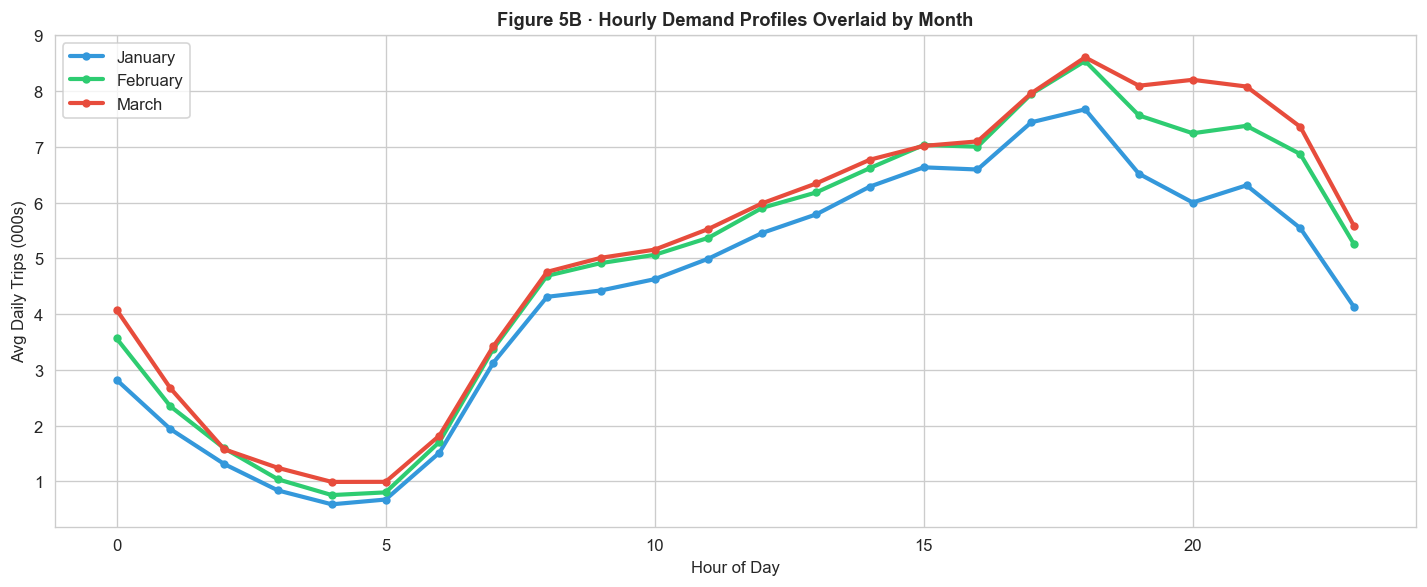

In [11]:
# How does the hourly demand pattern shift across January, February, March?
month_hour = (
    df.groupby(['pickup_month', 'pickup_hour'])
    .size()
    .reset_index(name='trips')
)

# Normalize by number of days per month to get avg daily trips per hour
days_per_month = {1: 31, 2: 28, 3: 31}
month_hour['avg_daily_trips'] = month_hour.apply(
    lambda r: r.trips / days_per_month[r.pickup_month], axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
month_colors = {1: '#3498db', 2: '#2ecc71', 3: '#e74c3c'}

for ax, month in zip(axes, [1, 2, 3]):
    mdata = month_hour[month_hour.pickup_month == month]
    ax.bar(mdata.pickup_hour, mdata.avg_daily_trips / 1000,
           color=month_colors[month], edgecolor='none', alpha=0.85)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Avg Hourly Trips (000s)' if ax == axes[0] else '')
    ax.set_title(f'{MONTH_MAP[month]} 2025')
    ax.set_xticks([0, 6, 12, 18, 23])

fig.suptitle('Figure 5 · Monthly Evolution of Hourly Demand Patterns (avg daily trips per hour)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Overlay version
fig, ax = plt.subplots(figsize=(12, 5))
for month, color in month_colors.items():
    mdata = month_hour[month_hour.pickup_month == month].sort_values('pickup_hour')
    ax.plot(mdata.pickup_hour, mdata.avg_daily_trips / 1000,
            color=color, lw=2.5, marker='o', markersize=4,
            label=MONTH_MAP[month])
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Daily Trips (000s)')
ax.set_title('Figure 5B · Hourly Demand Profiles Overlaid by Month')
ax.legend()
plt.tight_layout()
plt.show()

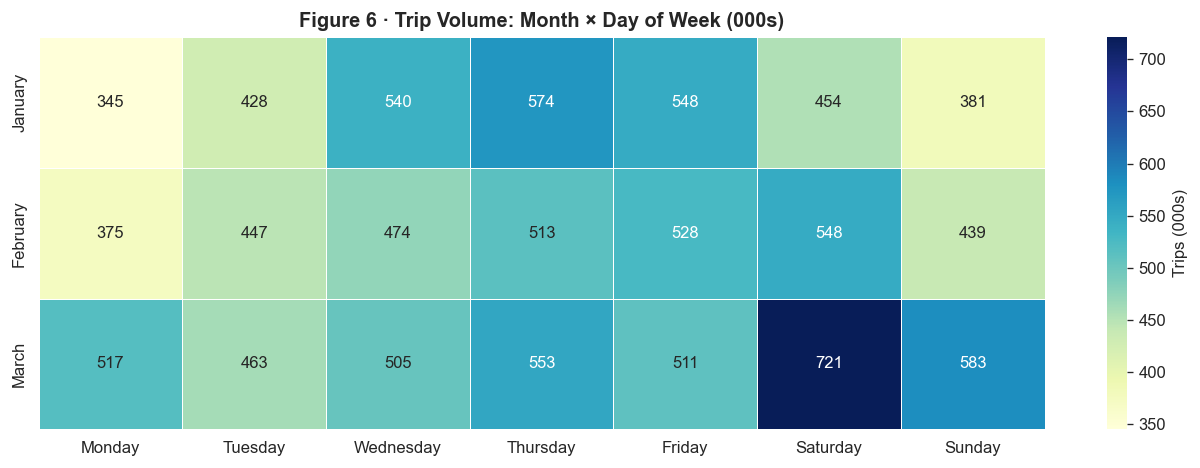

In [12]:
# ── Month × Day-of-Week × avg_total_amount ────────────────────────────────
month_dow = (
    df.groupby(['pickup_month', 'pickup_dow_name'])
    .agg(trips=('trip_id','count'), avg_total=('total_amount','mean'))
    .reset_index()
)

pivot_trips_mdow = (
    month_dow.pivot(index='pickup_month', columns='pickup_dow_name', values='trips')
    .reindex(columns=DOW_ORDER)
)

fig, ax = plt.subplots(figsize=(11, 4))
pivot_trips_mdow.index = [MONTH_MAP[m] for m in pivot_trips_mdow.index]
sns.heatmap(pivot_trips_mdow / 1000, cmap='YlGnBu', annot=True, fmt='.0f',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Trips (000s)'})
ax.set_title('Figure 6 · Trip Volume: Month × Day of Week (000s)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 5. Pre/Post CBD × Geography × Fare

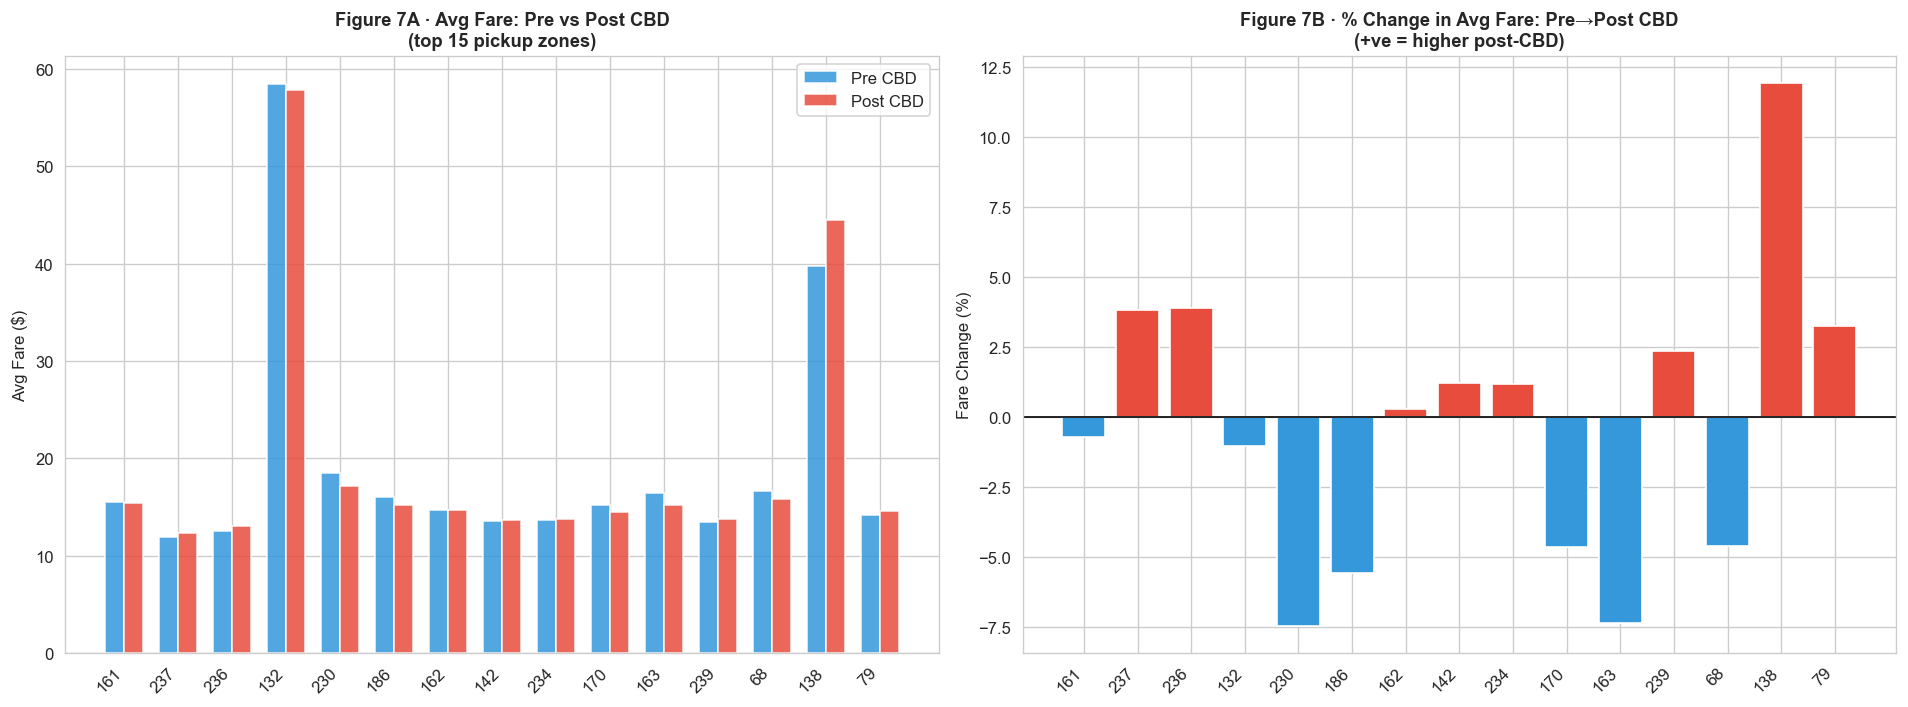

Pre/post CBD comparison by zone:
 zone  pre_avg_fare  post_avg_fare  pct_change
  138         39.73          44.47       11.93
  236         12.53          13.02        3.90
  237         11.91          12.37        3.82
   79         14.18          14.64        3.24
  239         13.44          13.76        2.35
  142         13.53          13.70        1.23
  234         13.64          13.81        1.20
  162         14.68          14.72        0.28
  161         15.52          15.41       -0.72
  132         58.42          57.82       -1.03
   68         16.60          15.84       -4.59
  170         15.18          14.48       -4.64
  186         16.07          15.18       -5.58
  163         16.44          15.23       -7.35
  230         18.52          17.14       -7.45


In [13]:
# For top 15 zones: compare avg fare pre vs post CBD fee introduction
top15_zones = df.groupby('PULocationID').size().nlargest(15).index.tolist()

cbd_geo = (
    df[df.PULocationID.isin(top15_zones)]
    .groupby(['PULocationID', 'is_post_cbd'])
    .agg(
        trips=('trip_id', 'count'),
        avg_fare=('fare_amount', 'mean'),
        avg_total=('total_amount', 'mean')
    )
    .reset_index()
)

# Pivot: zones vs (pre/post) × metric
pre_fare  = cbd_geo[~cbd_geo.is_post_cbd].set_index('PULocationID')['avg_fare'].reindex(top15_zones)
post_fare = cbd_geo[cbd_geo.is_post_cbd].set_index('PULocationID')['avg_fare'].reindex(top15_zones)
change_pct = ((post_fare - pre_fare) / pre_fare * 100).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar: pre vs post fare by zone
x = np.arange(len(top15_zones))
w = 0.35
axes[0].bar(x - w/2, pre_fare.values, w, label='Pre CBD', color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, post_fare.values, w, label='Post CBD', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(z) for z in top15_zones], rotation=45, ha='right')
axes[0].set_ylabel('Avg Fare ($)')
axes[0].set_title('Figure 7A · Avg Fare: Pre vs Post CBD\n(top 15 pickup zones)')
axes[0].legend()

# % change bar
colors_change = ['#e74c3c' if v > 0 else '#3498db' for v in change_pct.values]
axes[1].bar(range(len(top15_zones)), change_pct.values,
            color=colors_change, edgecolor='white')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xticks(range(len(top15_zones)))
axes[1].set_xticklabels([str(z) for z in top15_zones], rotation=45, ha='right')
axes[1].set_ylabel('Fare Change (%)')
axes[1].set_title('Figure 7B · % Change in Avg Fare: Pre→Post CBD\n(+ve = higher post-CBD)')

plt.tight_layout()
plt.show()

print('Pre/post CBD comparison by zone:')
zone_cbd_summary = pd.DataFrame({'zone': top15_zones,
                                   'pre_avg_fare': pre_fare.values.round(2),
                                   'post_avg_fare': post_fare.values.round(2),
                                   'pct_change': change_pct.values.round(2)})
print(zone_cbd_summary.sort_values('pct_change', ascending=False).to_string(index=False))

---
## 6. Vendor × Payment Type × Revenue

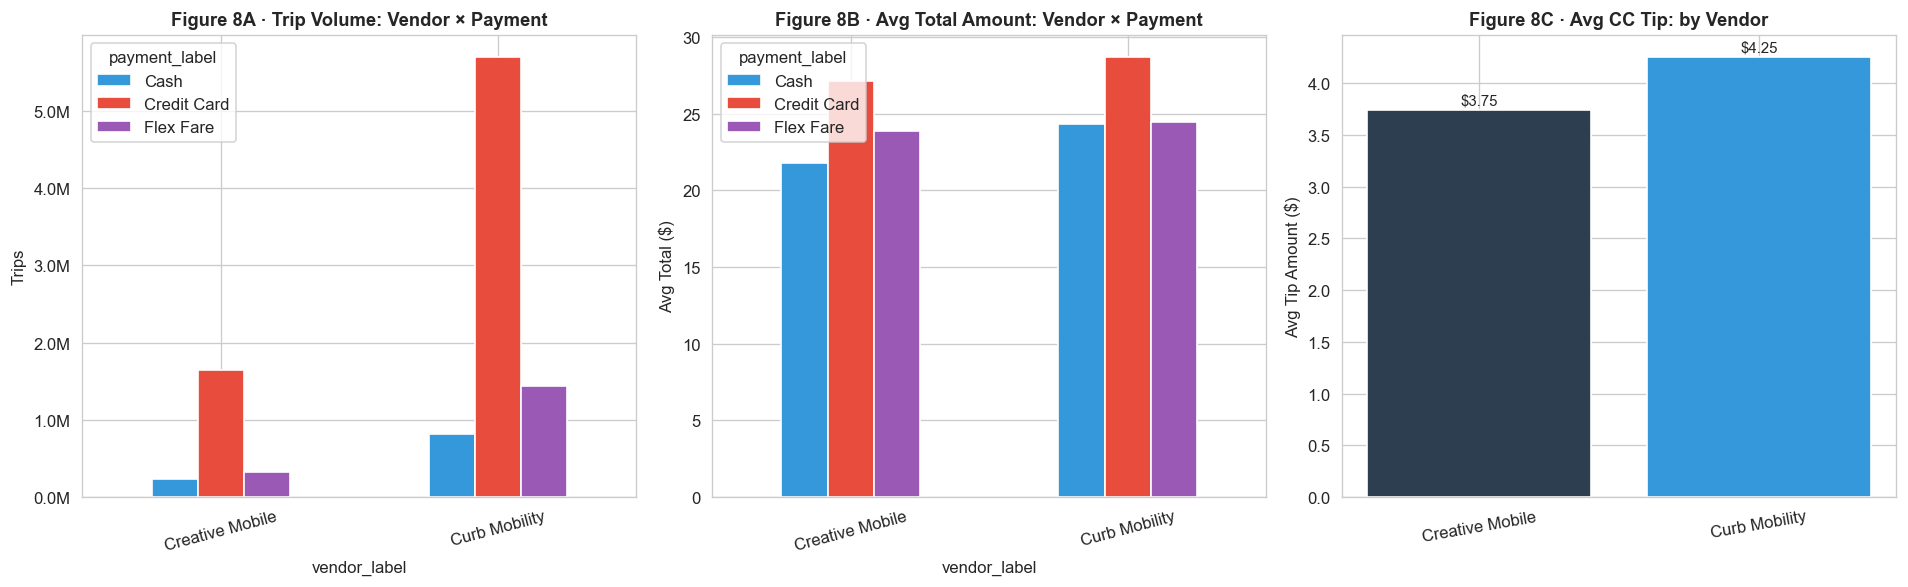

In [14]:
# Focus on main vendors (1, 2) and main payment types (0, 1, 2)
df_vp = df[df.VendorID.isin([1, 2]) & df.payment_type.isin([0, 1, 2])].copy()
df_vp['vendor_label']  = df_vp.VendorID.map(VENDOR_LABELS)
df_vp['payment_label'] = df_vp.payment_type.map(PT_LABELS)

vp = (
    df_vp.groupby(['vendor_label', 'payment_label'])
    .agg(
        trips=('trip_id', 'count'),
        avg_total=('total_amount', 'mean'),
        total_revenue=('total_amount', 'sum'),
        avg_tip=('tip_amount', 'mean')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Trip volume: vendor × payment
pivot_v = vp.pivot(index='vendor_label', columns='payment_label', values='trips').fillna(0)
pivot_v.plot(kind='bar', ax=axes[0], color=['#3498db','#e74c3c','#9b59b6'],
             edgecolor='white')
axes[0].set_title('Figure 8A · Trip Volume: Vendor × Payment')
axes[0].set_ylabel('Trips')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Avg total: vendor × payment
pivot_avg = vp.pivot(index='vendor_label', columns='payment_label', values='avg_total').fillna(0)
pivot_avg.plot(kind='bar', ax=axes[1], color=['#3498db','#e74c3c','#9b59b6'],
               edgecolor='white')
axes[1].set_title('Figure 8B · Avg Total Amount: Vendor × Payment')
axes[1].set_ylabel('Avg Total ($)')
axes[1].tick_params(axis='x', rotation=15)

# Avg tip: vendor × payment (credit card only)
vp_cc = vp[vp.payment_label == 'Credit Card'].set_index('vendor_label')
axes[2].bar(vp_cc.index, vp_cc.avg_tip,
            color=['#2c3e50', '#3498db'], edgecolor='white')
for i, v in enumerate(vp_cc.avg_tip):
    axes[2].text(i, v + 0.05, f'${v:.2f}', ha='center', fontsize=9)
axes[2].set_title('Figure 8C · Avg CC Tip: by Vendor')
axes[2].set_ylabel('Avg Tip Amount ($)')
axes[2].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

---
## 7. Pair Plot — Core Financial & Operational Variables

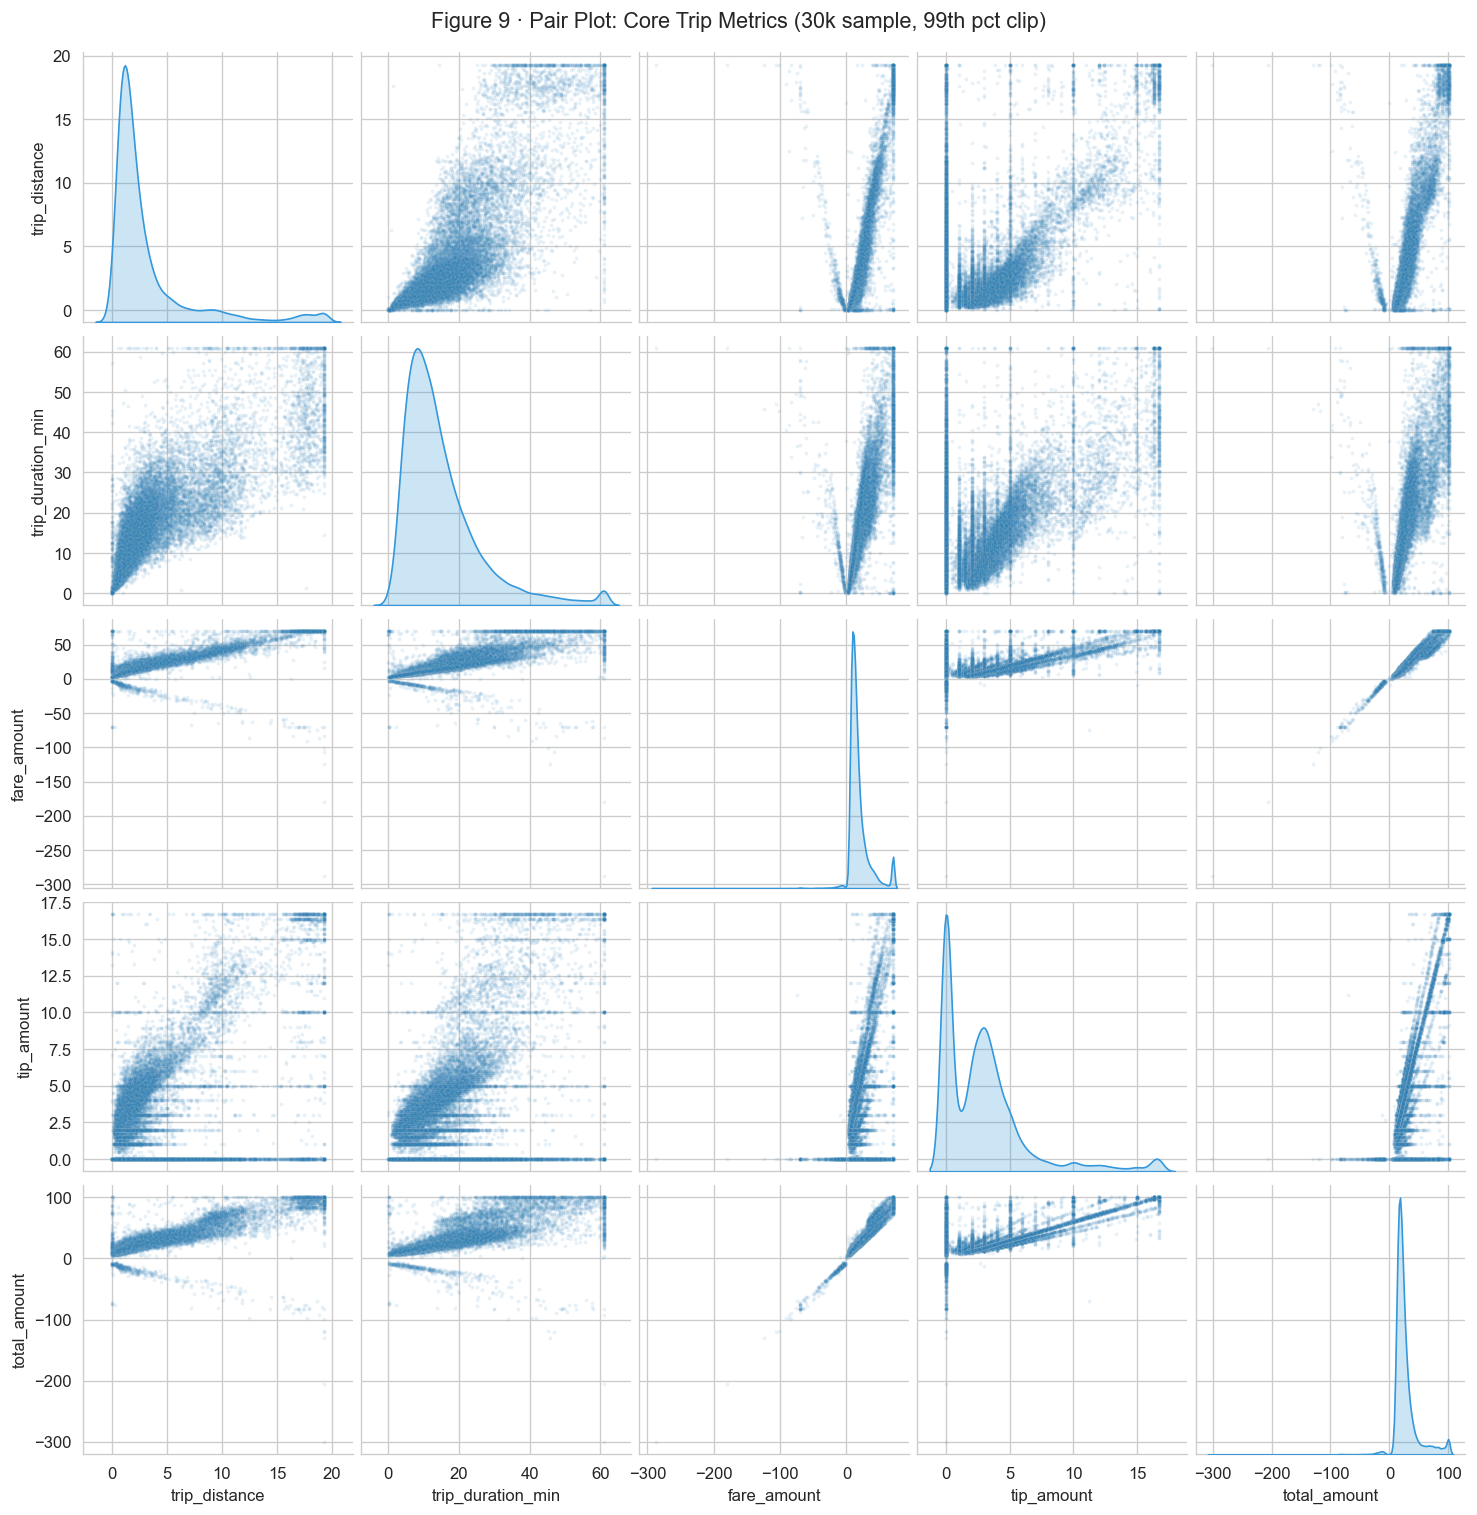

In [15]:
# Sample for performance
pair_cols = ['trip_distance', 'trip_duration_min', 'fare_amount',
             'tip_amount', 'total_amount']

sample_pair = df[pair_cols].sample(min(30_000, len(df)), random_state=42)

# Cap at 99th percentile
for col in pair_cols:
    cap = sample_pair[col].quantile(0.99)
    sample_pair[col] = sample_pair[col].clip(upper=cap)

fig = sns.pairplot(sample_pair, diag_kind='kde', plot_kws={'alpha': 0.1, 's': 5},
                   diag_kws={'color': '#3498db', 'shade': True})
fig.fig.suptitle('Figure 9 · Pair Plot: Core Trip Metrics (30k sample, 99th pct clip)',
                  fontsize=13, y=1.01)
plt.show()

---
## 8. Weekend vs Weekday × Hour × Payment Type

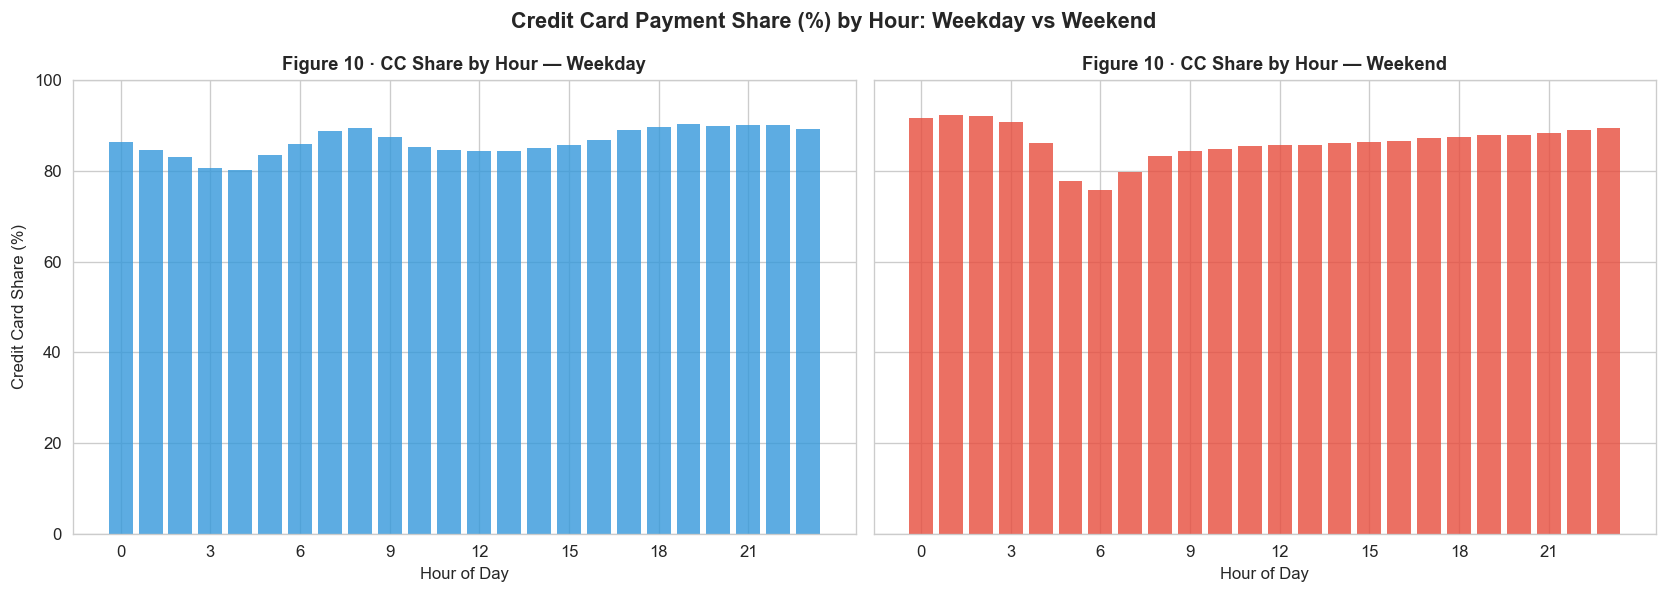

In [16]:
# Small multiples: Credit Card share by hour — weekday vs weekend
df_hr = df[df.payment_type.isin([1, 2])].copy()
df_hr['cc_flag'] = (df_hr.payment_type == 1).astype(int)

hr_wd = df_hr.groupby(['pickup_hour', 'is_weekend'])['cc_flag'].agg(['mean','count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, weekend, label, color in [
    (axes[0], False, 'Weekday', '#3498db'),
    (axes[1], True,  'Weekend', '#e74c3c')
]:
    sub = hr_wd[hr_wd.is_weekend == weekend]
    ax.bar(sub.pickup_hour, sub['mean'] * 100, color=color, alpha=0.8, edgecolor='none')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Credit Card Share (%)' if ax == axes[0] else '')
    ax.set_title(f'Figure 10 · CC Share by Hour — {label}')
    ax.set_xticks(range(0, 24, 3))
    ax.set_ylim(0, 100)

plt.suptitle('Credit Card Payment Share (%) by Hour: Weekday vs Weekend',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Multivariate Executive Summary

In [18]:
print('=' * 60)
print('  OW YELLOW CAPS — MULTIVARIATE EDA KEY FINDINGS')
print('=' * 60)

# 1. Peak time-geography combination
top_combo = (
    df.groupby(['pickup_hour', 'PULocationID'])
    .size().reset_index(name='trips')
    .nlargest(3, 'trips')
)
print('\n1. TOP 3 Hour × Zone combinations by volume:')
print(top_combo.to_string(index=False))

# 2. CBD impact
pre_avg  = df[~df.is_post_cbd].total_amount.mean()
post_avg = df[df.is_post_cbd].total_amount.mean()
pct_chg  = (post_avg - pre_avg) / pre_avg * 100
print(f'\n2. CBD fee impact on avg total amount: {pct_chg:+.2f}% (${pre_avg:.2f} → ${post_avg:.2f})')

# 3. Best revenue zone
best_rev_zone = (
    df.groupby('PULocationID')['total_amount'].sum().idxmax()
)
best_rev_val = df.groupby('PULocationID')['total_amount'].sum().max()
print(f'\n3. Highest revenue pickup zone: Zone {best_rev_zone} (${best_rev_val/1e6:.2f}M total)')

# 4. CC vs cash avg total
cc_avg   = df[df.payment_type == 1].total_amount.mean()
cash_avg = df[df.payment_type == 2].total_amount.mean()
print(f'\n4. Avg total: Credit Card ${cc_avg:.2f} vs Cash ${cash_avg:.2f}')

# 5. Peak day × hour
peak_dh = (
    df.groupby(['pickup_dow_name', 'pickup_hour'])
    .size().reset_index(name='trips')
    .nlargest(1, 'trips').iloc[0]
)
print(f'\n5. Single busiest hour: {peak_dh.pickup_dow_name} at {int(peak_dh.pickup_hour)}:00 '
      f'({peak_dh.trips:,} trips)')

print('\n' + '=' * 60)

  OW YELLOW CAPS — MULTIVARIATE EDA KEY FINDINGS

1. TOP 3 Hour × Zone combinations by volume:
 pickup_hour  PULocationID  trips
          18           161  46268
          17           161  45353
          19           161  39022

2. CBD fee impact on avg total amount: -2.06% ($27.14 → $26.58)

3. Highest revenue pickup zone: Zone 132 ($31.27M total)

4. Avg total: Credit Card $28.35 vs Cash $23.78

5. Single busiest hour: Thursday at 18:00 (122,673 trips)

